# Value at Risk and SVJD Distributional Simulation

## Introduction

- We read in previously computed time-varying volatility measures for the S&P 500.
- We use these measures to illustrate one-day Value at Risk (VaR).
- We then estimate a Stochastic Volatility Jump Diffusion (SVJD) model by simulated GMM.
- **Important distinction:** the SVJD simulations in this notebook are **not forecasts of the realized S&P 500 time series**. They are synthetic draws generated by the estimated stochastic process.
- Their purpose is to reproduce important **distributional and dependence properties** of historical returns—mean, variance, skewness, kurtosis, tail quantiles, and selected autocorrelations—and then to characterize risk measures such as VaR, Expected Shortfall, and tail probabilities.


In [5]:
   # If needed:
# %pip install yfinance arch scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import course_tools_general as ctg


# Download data for any ticker directly into your target variable
spx = ctg.load_prices(ticker="^GSPC", start="1990-01-01")
spx.head()

print(f"S&P 500 sample: {spx.index.min().date()} to {spx.index.max().date()}")

# These range measures were introduced in Class 2.
# Reuse them here without requiring the Class 2 kernel to remain open.
gk20 = ctg.garman_klass_rolling(spx, window=20).to_numpy()
ok20 = ctg.ok_rolling(spx, window=20).to_numpy()




# GJR-GARCH-in-Mean was taught in Class 3.  Re-estimate it here quietly
# so this notebook can be run independently after a kernel restart.
gjr_daily_vol, garch_m_lev_results = ctg.fit_gjr_garch_in_mean_volatility(spx, nlags=5)





S&P 500 sample: 1990-01-02 to 2026-08-28


- We plot the previously computed data as well as the daily S&P 500 returns.

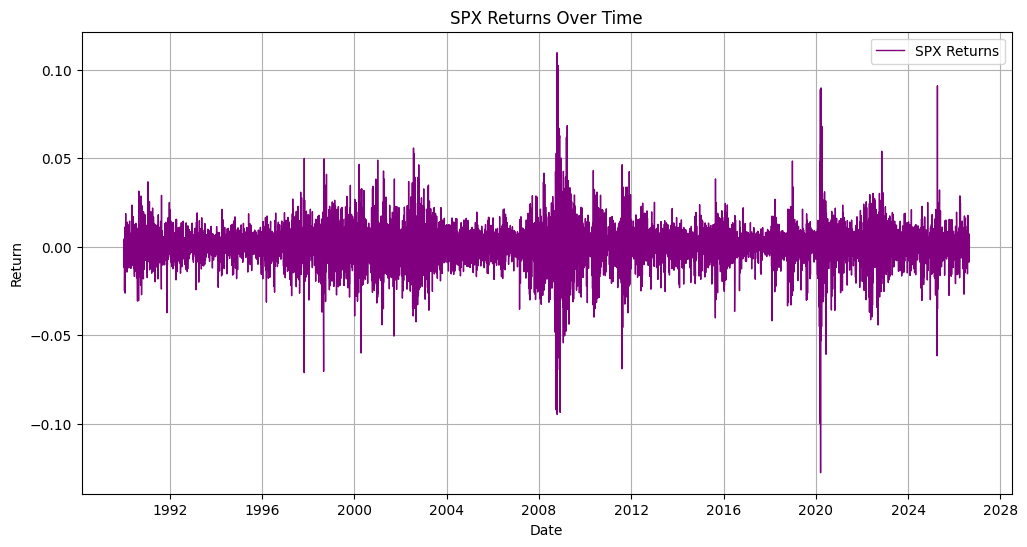

In [6]:
import matplotlib.pyplot as plt

# Plot the SPX returns
plt.figure(figsize=(12, 6))
plt.plot(spx.index, spx['Return'], label='SPX Returns', color='purple', linewidth=1)
plt.title('SPX Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Return')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
print(spx.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Log_Close', 'Log_Open',
       'Log_High', 'Log_Low', 'Return'],
      dtype='str', name='Price')


C:\Users\Saint110676\AppData\Local\Temp\ipykernel_2420\3733179458.py:54: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  ann_df = pd.concat(


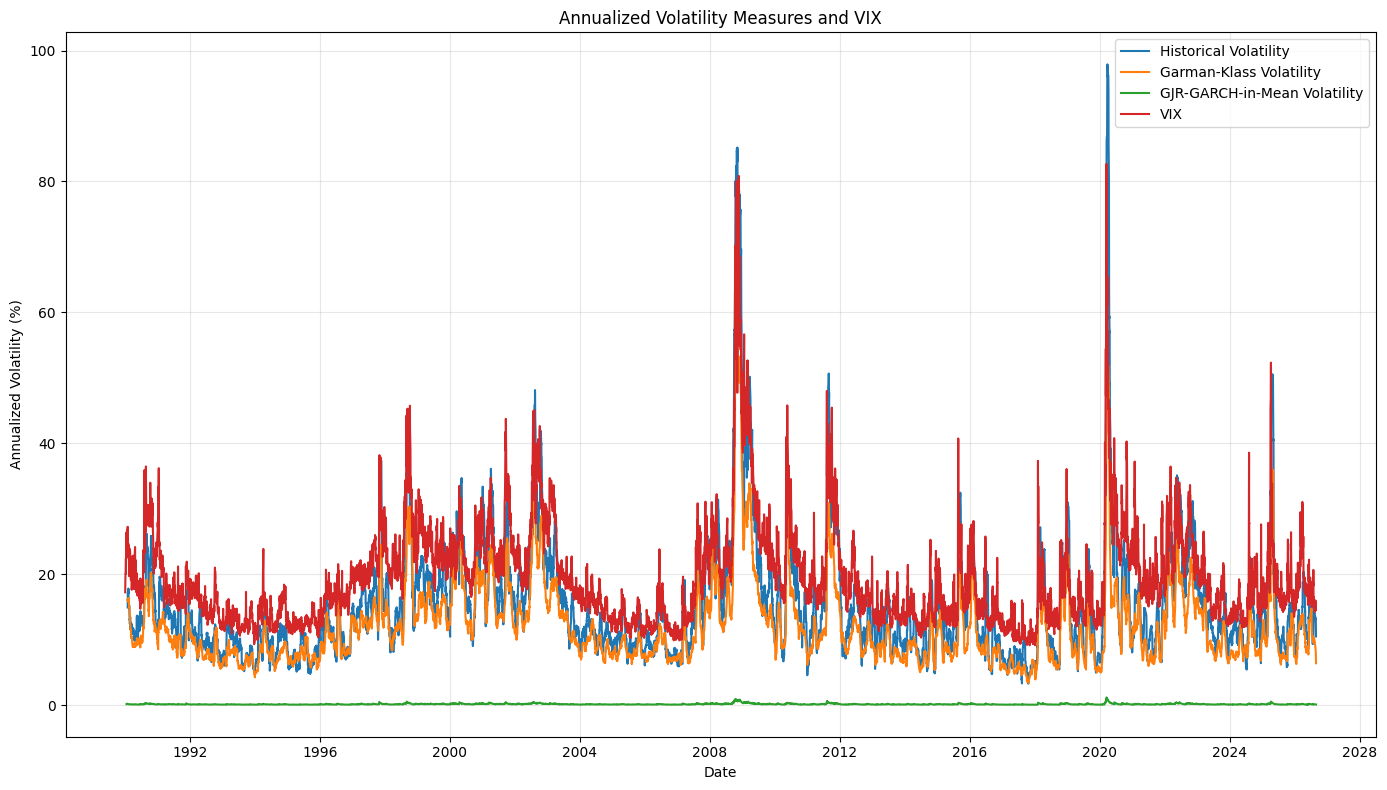

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Historical volatility: 20-day rolling std. dev.
#    Annualized and expressed in percent
# --------------------------------------------------

historical_vol = (
    spx["Return"]
    .rolling(window=20)
    .std()
    * np.sqrt(252)
    * 100
)

# --------------------------------------------------
# 2. Garman-Klass volatility
#    gk20 is daily volatility in decimal form
# --------------------------------------------------

gk_vol = (
    pd.Series(gk20, index=spx.index)
    * np.sqrt(252)
    * 100
)

# --------------------------------------------------
# 3. GJR-GARCH-in-Mean volatility
#    gjr_daily_vol is daily volatility in percent
# --------------------------------------------------

gjr_vol = pd.Series(
    np.asarray(gjr_daily_vol),
    index=spx.index[-len(gjr_daily_vol):]
)

gjr_vol_annual = gjr_vol * np.sqrt(252)

# --------------------------------------------------
# 4. Download VIX directly
#    VIX is already quoted as annualized percent volatility
# --------------------------------------------------

vix = ctg.load_prices(ticker="^VIX", start="1990-01-01")

vix_series = vix["Close"].rename("VIX")

# --------------------------------------------------
# 5. Combine all measures by date
# --------------------------------------------------

ann_df = pd.concat(
    [
        historical_vol.rename("Historical_Vol"),
        gk_vol.rename("GK_Vol"),
        gjr_vol_annual.rename("GJR_GARCH_M_Vol"),
        vix_series
    ],
    axis=1
)

# --------------------------------------------------
# 6. Plot
# --------------------------------------------------

plt.figure(figsize=(14, 8))

plt.plot(
    ann_df.index,
    ann_df["Historical_Vol"],
    label="Historical Volatility"
)

plt.plot(
    ann_df.index,
    ann_df["GK_Vol"],
    label="Garman-Klass Volatility"
)

plt.plot(
    ann_df.index,
    ann_df["GJR_GARCH_M_Vol"],
    label="GJR-GARCH-in-Mean Volatility"
)

plt.plot(
    ann_df.index,
    ann_df["VIX"],
    label="VIX"
)

plt.title("Annualized Volatility Measures and VIX")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility (%)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

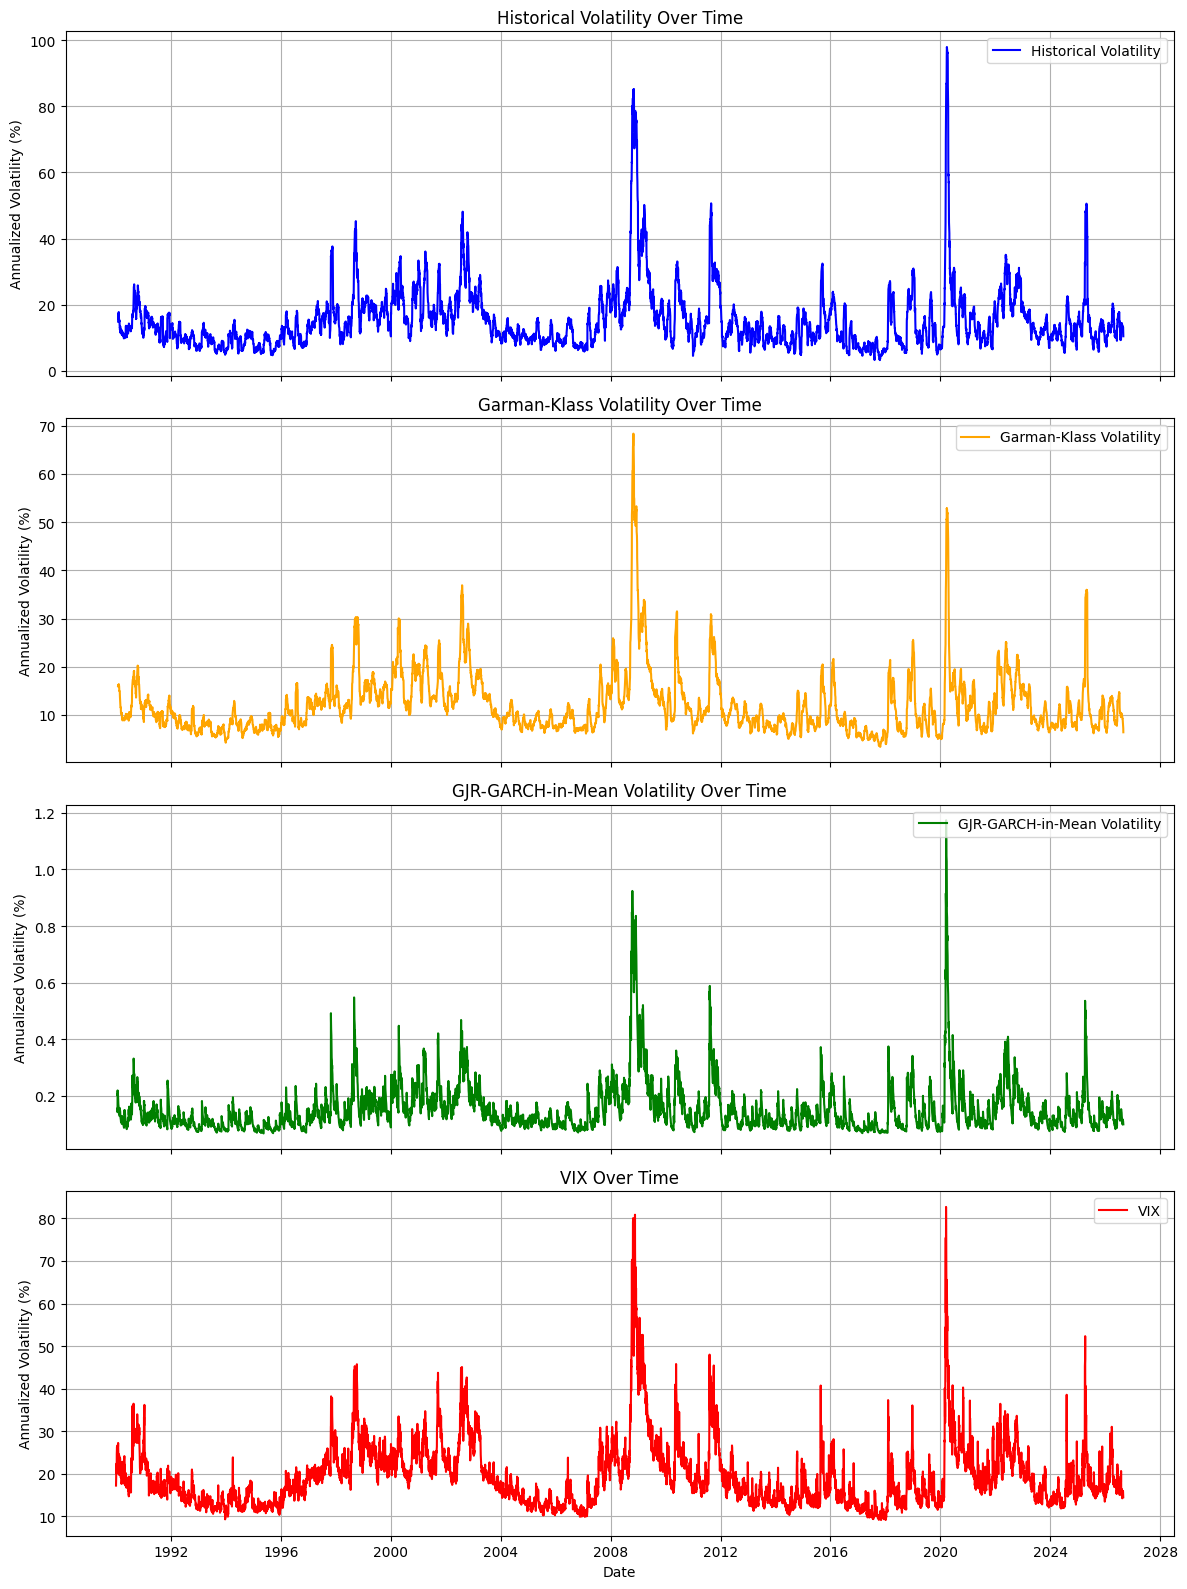

In [11]:
import matplotlib.pyplot as plt

# Define column names consistent with ann_df
historical_vol_col = 'Historical_Vol'
gk_vol_col = 'GK_Vol'
garch_vol_col = 'GJR_GARCH_M_Vol'
vix_col = 'VIX'

# Create subplots
fig, axs = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

# Historical Volatility
axs[0].plot(
    ann_df.index,
    ann_df[historical_vol_col],
    label='Historical Volatility',
    color='blue'
)
axs[0].set_title('Historical Volatility Over Time')
axs[0].set_ylabel('Annualized Volatility (%)')
axs[0].legend(loc='upper right')
axs[0].grid(True)

# Garman-Klass Volatility
axs[1].plot(
    ann_df.index,
    ann_df[gk_vol_col],
    label='Garman-Klass Volatility',
    color='orange'
)
axs[1].set_title('Garman-Klass Volatility Over Time')
axs[1].set_ylabel('Annualized Volatility (%)')
axs[1].legend(loc='upper right')
axs[1].grid(True)

# GJR-GARCH-in-Mean Volatility
axs[2].plot(
    ann_df.index,
    ann_df[garch_vol_col],
    label='GJR-GARCH-in-Mean Volatility',
    color='green'
)
axs[2].set_title('GJR-GARCH-in-Mean Volatility Over Time')
axs[2].set_ylabel('Annualized Volatility (%)')
axs[2].legend(loc='upper right')
axs[2].grid(True)

# VIX
axs[3].plot(
    ann_df.index,
    ann_df[vix_col],
    label='VIX',
    color='red'
)
axs[3].set_title('VIX Over Time')
axs[3].set_xlabel('Date')
axs[3].set_ylabel('Annualized Volatility (%)')
axs[3].legend(loc='upper right')
axs[3].grid(True)

plt.tight_layout()
plt.show()

- For clarity we also plot these uncertainty measures on four separate charts.

## One-Day Value at Risk

**Value at Risk (VaR)** summarizes the lower tail of the return distribution over a specified horizon.

For a normally distributed one-day return, the lower-tail threshold at probability \(\alpha\) is

\[
q_\alpha = \mu + z_\alpha \sigma,
\]

where \(\mu\) is the mean daily return, \(\sigma\) is daily volatility, and \(z_\alpha\) is the standard-normal lower-tail quantile.

- 5% lower tail: \(z_{0.05}\approx -1.645\)
- 1% lower tail: \(z_{0.01}\approx -2.326\)

In this notebook VaR is reported as a **return threshold**, so a more negative number represents a larger loss.

The time-varying volatility measures below can produce time-varying one-day VaR estimates. A GARCH model can also be used for conditional volatility forecasting. This is conceptually different from the later SVJD exercise: the SVJD simulation is used here to estimate and study the **return distribution**, not to forecast the exact future path of returns.

### Volatility measures used

1. **Historical volatility** — based on past return variation.
2. **Range volatility (GK)** — uses open, high, low, and close information.
3. **GARCH volatility** — models conditional, time-varying volatility.
4. **VIX** — an option-implied measure of expected market volatility.


In [13]:
import numpy as np

# Work with the annualized-volatility DataFrame
df = ann_df.copy()

# Add daily S&P 500 return
df["Return"] = spx["Return"].reindex(df.index)

# Annualized volatility columns
vol_cols = [
    "Historical_Vol",
    "GK_Vol",
    "GJR_GARCH_M_Vol",
    "VIX"
]

# Convert annualized percent volatility to daily decimal volatility
for col in vol_cols:
    df[col + "_daily"] = (df[col] / 100) / np.sqrt(252)

# Mean daily S&P 500 return
mean_return = df["Return"].mean()

# Historical volatility VaR
df["VaR_5_Hist"] = (
    mean_return - 1.645 * df["Historical_Vol_daily"]
)

df["VaR_1_Hist"] = (
    mean_return - 2.33 * df["Historical_Vol_daily"]
)

# Garman-Klass VaR
df["VaR_5_GK"] = (
    mean_return - 1.645 * df["GK_Vol_daily"]
)

df["VaR_1_GK"] = (
    mean_return - 2.33 * df["GK_Vol_daily"]
)

# GJR-GARCH-in-Mean VaR
df["VaR_5_GARCH"] = (
    mean_return - 1.645 * df["GJR_GARCH_M_Vol_daily"]
)

df["VaR_1_GARCH"] = (
    mean_return - 2.33 * df["GJR_GARCH_M_Vol_daily"]
)

# VIX-based VaR
df["VaR_5_VIX"] = (
    mean_return - 1.645 * df["VIX_daily"]
)

df["VaR_1_VIX"] = (
    mean_return - 2.33 * df["VIX_daily"]
)

### Plot of 5% one-day VaR measures

The following plot compares the 5% lower-tail return threshold implied by the four volatility measures. These are **conditional risk measures**, not forecasts of the actual next return.


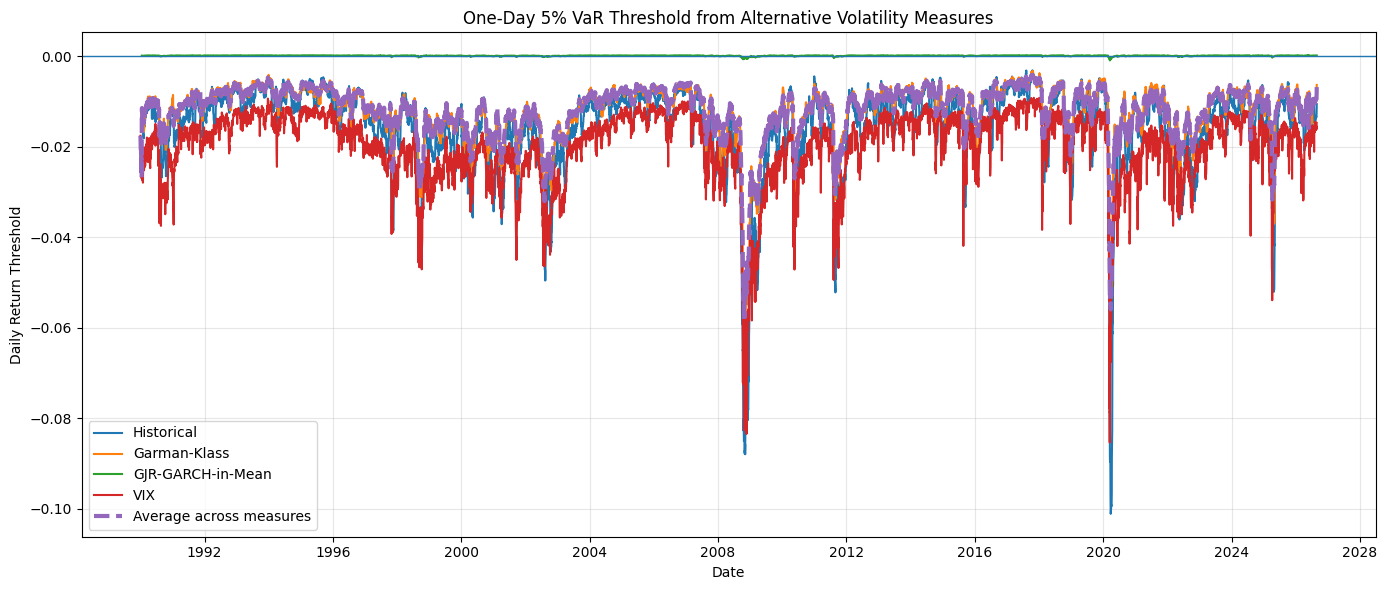

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Work with the annualized-volatility DataFrame
df = ann_df.copy()

# Add daily S&P 500 returns
df["Return"] = spx["Return"].reindex(df.index)

# Volatility measures
vol_cols = [
    "Historical_Vol",
    "GK_Vol",
    "GJR_GARCH_M_Vol",
    "VIX"
]

# Convert annualized percent volatility to daily decimal volatility
for col in vol_cols:
    df[col + "_daily"] = (df[col] / 100) / np.sqrt(252)

# Mean daily return and 5% critical value
mu_daily = df["Return"].mean()
z_05 = 1.645

# Calculate one-day 5% VaR threshold for each volatility measure
for col in vol_cols:
    df["VaR_5_" + col] = (
        mu_daily - z_05 * df[col + "_daily"]
    )

# VaR column names
var_cols = ["VaR_5_" + col for col in vol_cols]

# Average VaR across the four volatility measures
df["Average_VaR_5"] = df[var_cols].mean(axis=1)

# Plot
plt.figure(figsize=(14, 6))

labels = {
    "VaR_5_Historical_Vol": "Historical",
    "VaR_5_GK_Vol": "Garman-Klass",
    "VaR_5_GJR_GARCH_M_Vol": "GJR-GARCH-in-Mean",
    "VaR_5_VIX": "VIX"
}

for col in var_cols:
    plt.plot(
        df.index,
        df[col],
        label=labels[col]
    )

plt.plot(
    df.index,
    df["Average_VaR_5"],
    label="Average across measures",
    linewidth=3,
    linestyle="--"
)

plt.axhline(0, linewidth=1)

plt.title("One-Day 5% VaR Threshold from Alternative Volatility Measures")
plt.ylabel("Daily Return Threshold")
plt.xlabel("Date")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()


In [16]:
r_actual_series = spx['Return'].dropna()
r_actual = r_actual_series.to_numpy()
dates = pd.to_datetime(r_actual_series.index)


## Stochastic Volatility Jump Diffusion (SVJD) Process

### Why Use a Stochastic Volatility Jump Diffusion Model?

The volatility models considered earlier, such as GARCH and GJR-GARCH, allow volatility to change over time as a function of past observed returns and past shocks.

A **Stochastic Volatility Jump Diffusion (SVJD)** model takes a different approach. It treats volatility itself as an **unobserved stochastic process** that is continually affected by its own random shocks.

There are therefore three important sources of uncertainty:

1. a continuous shock to the **return**,
2. a continuous shock to **volatility**,
3. an occasional **jump shock** to the return.

This additional structure is useful because financial returns display several features that are difficult to reproduce with a simple Normal model:

- volatility changes randomly through time,
- high-volatility periods tend to persist,
- volatility eventually tends to return toward a long-run level,
- negative return shocks are often associated with increases in volatility,
- unusually large positive and negative returns occur more frequently than predicted by a Normal distribution,
- financial crises and major announcements can produce abrupt movements that look more like jumps than ordinary daily fluctuations.

Thus, the SVJD model attempts to reproduce not simply the average return and variance, but also important features such as **volatility clustering, leverage effects, skewness, fat tails, and extreme returns**.

---

### What the Simulation Is—and Is Not

An estimated SVJD model defines a **stochastic data-generating process** for returns and latent variance.

A simulated path represents one possible synthetic history that could have been generated by this process.

The objective is therefore not to reproduce the historical S&P 500 return on each particular date. Instead, we want the simulated data to have statistical properties resembling those of actual financial returns.

A simulated SVJD model can be useful for:

- reproducing the empirical return distribution,
- reproducing volatility clustering,
- reproducing skewness and fat tails,
- studying extreme return probabilities,
- calculating Value-at-Risk (VaR),
- calculating Expected Shortfall,
- generating stress scenarios,
- studying how return and volatility shocks interact.

It is **not** appropriate to place one simulated path beside the historical S&P 500 series and interpret closeness date-by-date as forecast accuracy.

The simulated return at date $t$ is simply one random realization from the estimated stochastic process. It is not intended to reproduce the particular historical return that actually occurred on that date.

---

## The SVJD Model

Let $v_t$ denote the annualized instantaneous variance of returns.

Since we are working with daily observations, define

$$
dt = \frac{1}{252}.
$$

The model consists of two interacting continuous stochastic processes:

1. a process for variance $v_t$,
2. a process for returns $r_t$.

A separate jump process is then added to allow for occasional unusually large movements in returns.

---

## 1. The Stochastic Variance Process

The variance process is

$$
v_t
=
v_{t-1}
+
\kappa(\theta-v_{t-1})dt
+
\sigma_v
\sqrt{\max(v_{t-1},0)}
\sqrt{dt}\,z_{2t}.
$$

There are three components in this equation.

### Previous Variance

The first component is

$$
v_{t-1}.
$$

Today's variance begins with yesterday's variance.

This creates persistence in volatility. A period of unusually high volatility therefore tends to be followed by another period of relatively high volatility rather than volatility immediately returning to its normal level.

This is one source of **volatility clustering**.

---

### Mean Reversion

The second component is

$$
\kappa(\theta-v_{t-1})dt.
$$

Here,

- $\theta$ is the long-run level of variance,
- $\kappa$ measures the speed at which variance returns toward $\theta$.

Suppose current variance is above its long-run level:

$$
v_{t-1}>\theta.
$$

Then

$$
\theta-v_{t-1}<0,
$$

so this component pushes variance downward.

If instead

$$
v_{t-1}<\theta,
$$

then

$$
\theta-v_{t-1}>0,
$$

and the mean-reversion component pushes variance upward.

Thus, volatility can remain high for some time following a crisis, but there is a tendency for it eventually to return toward its long-run level.

The parameter $\kappa$ determines how quickly this mean reversion occurs.

---

### The Volatility Shock

The final component is

$$
\sigma_v
\sqrt{\max(v_{t-1},0)}
\sqrt{dt}\,z_{2t}.
$$

The random variable $z_{2t}$ represents the **shock to volatility**.

The parameter

$$
\sigma_v
$$

is often called the **volatility of volatility**.

A larger value of $\sigma_v$ means that the variance process itself can experience larger random fluctuations.

Notice that the size of the volatility shock also depends on

$$
\sqrt{v_{t-1}}.
$$

Thus, fluctuations in variance tend to become larger when the market is already in a high-volatility state.

The expression

$$
\sqrt{\max(v_{t-1},0)}
$$

is used in the discrete-time simulation as a numerical safeguard so that we never attempt to take the square root of a negative simulated variance.

---

## 2. The Return Process

The return process is

$$
r_t
=
\left(\mu-\frac{1}{2}v_{t-1}\right)dt
+
\sqrt{v_{t-1}}\sqrt{dt}\,z_{1t}
+
J_t^{\text{total}}.
$$

There are three components.

### Expected Return

The first component is

$$
\left(\mu-\frac{1}{2}v_{t-1}\right)dt.
$$

The parameter $\mu$ represents the drift or expected growth component of the underlying asset process.

Since

$$
dt=\frac{1}{252},
$$

the annualized drift is converted into a daily contribution to the return.

---

### The Continuous Return Shock

The second component is

$$
\sqrt{v_{t-1}}\sqrt{dt}\,z_{1t}.
$$

The variable $z_{1t}$ represents the **continuous shock directly affecting the return**.

We assume

$$
z_{1t}\sim N(0,1).
$$

If $z_{1t}$ is positive, it contributes to a positive return.

If $z_{1t}$ is negative, it contributes to a negative return.

Importantly, the magnitude of the return shock depends on the current level of variance:

$$
\text{Return Shock}
=
\sqrt{v_{t-1}}\sqrt{dt}\,z_{1t}.
$$

Thus, the same realization of $z_{1t}$ produces a much larger movement in returns when the market is already in a high-volatility state.

---

## 3. The Two Continuous Shocks: $z_{1t}$ and $z_{2t}$

A central feature of the stochastic-volatility model is that the shock to returns and the shock to volatility are allowed to be **correlated**.

They have different economic meanings:

$$
z_{1t}
=
\text{return shock},
$$

while

$$
z_{2t}
=
\text{volatility shock}.
$$

Start with two independent standard Normal random variables,

$$
z_{1t}\sim N(0,1)
$$

and

$$
\varepsilon_t\sim N(0,1).
$$

We construct the volatility shock as

$$
z_{2t}
=
\rho z_{1t}
+
\sqrt{1-\rho^2}\,\varepsilon_t.
$$

This construction ensures that

$$
z_{2t}\sim N(0,1),
$$

but also that

$$
\text{Corr}(z_{1t},z_{2t})=\rho.
$$

Thus, $\rho$ controls the relationship between shocks to returns and shocks to volatility.

---

### Why Is $\rho$ Important?

For equity returns, we often expect

$$
\rho<0.
$$

This allows the model to reproduce the familiar **leverage effect**:

> Large negative stock-market returns tend to be associated with increases in volatility.

Suppose there is a negative return shock,

$$
z_{1t}<0.
$$

If

$$
\rho<0,
$$

then

$$
\rho z_{1t}>0.
$$

Since

$$
z_{2t}
=
\rho z_{1t}
+
\sqrt{1-\rho^2}\varepsilon_t,
$$

a large negative realization of $z_{1t}$ tends to push $z_{2t}$ upward.

A positive volatility shock $z_{2t}$ then raises variance through

$$
\sigma_v
\sqrt{v_{t-1}}
\sqrt{dt}\,z_{2t}.
$$

Therefore, when $\rho<0$,

$$
\boxed{
\text{Negative Return Shock}
\quad\Longrightarrow\quad
\text{Positive Volatility Shock}
\quad\Longrightarrow\quad
\text{Higher Volatility}
}
$$

This is closely related to the leverage effect studied earlier with GJR-GARCH.

The important difference is how the asymmetry enters the model.

In GJR-GARCH, negative past return innovations enter the variance equation differently from positive innovations.

In stochastic volatility, the asymmetry can arise because the **return shock and the volatility shock are negatively correlated**.

---

## 4. The Jump Process

The continuous return shock $z_{1t}$ can generate large movements, particularly when volatility is already high.

However, financial markets occasionally experience movements that are unusually abrupt. These may occur following major policy announcements, financial crises, geopolitical events, unexpected economic news, or other major shocks.

The SVJD model therefore introduces a separate **jump process**.

Let

$$
\mathcal{J}_t
$$

denote the **number of jumps occurring during trading day $t$**.

We assume that the jump count follows a Poisson distribution:

$$
\mathcal{J}_t
\sim
\text{Poisson}(\lambda dt).
$$

This notation distinguishes the Poisson **jump-count process** $\mathcal{J}_t$ from the Normal distributions used elsewhere in the model.

The parameter $\lambda$ controls the average frequency of jumps.

Since

$$
dt=\frac{1}{252},
$$

if $\lambda$ is measured as the expected number of jumps per year, then

$$
\lambda dt
=
\frac{\lambda}{252}
$$

is the expected number of jumps during one trading day.

On most days,

$$
\mathcal{J}_t=0.
$$

Occasionally,

$$
\mathcal{J}_t=1,
$$

and with much smaller probability,

$$
\mathcal{J}_t>1.
$$

Thus, the Poisson process determines **whether a jump occurs and how many jumps occur**.

---

### The Size of a Jump

Conditional on a jump occurring, let

$$
J_{tj}
$$

denote the size of jump $j$ on day $t$.

We assume

$$
J_{tj}
\sim
N(\mu_J,\sigma_J^2).
$$

Here,

- $\mu_J$ determines the average size and direction of an individual jump,
- $\sigma_J$ determines the variability of individual jump sizes.

For example, if

$$
\mu_J<0,
$$

then jumps tend, on average, to be negative.

However, because jump sizes are random, both positive and negative jumps remain possible.

---

### Total Jump Effect on the Return

If $\mathcal{J}_t$ jumps occur during day $t$, the total jump contribution to the return is

$$
J_t^{\text{total}}
=
\sum_{j=1}^{\mathcal{J}_t}J_{tj}.
$$

If no jump occurs,

$$
\mathcal{J}_t=0,
$$

then

$$
J_t^{\text{total}}=0.
$$

If exactly one jump occurs,

$$
\mathcal{J}_t=1,
$$

then

$$
J_t^{\text{total}}=J_{t1}.
$$

If several jumps occur, their effects are added together.

Conditional on observing

$$
\mathcal{J}_t=k>0,
$$

the total jump effect satisfies

$$
J_t^{\text{total}}
\mid
\mathcal{J}_t=k
\sim
N(k\mu_J,k\sigma_J^2).
$$

Thus, the jump part of the model has two separate pieces:

$$
\boxed{
\mathcal{J}_t
=
\text{How many jumps occur}
}
$$

and

$$
\boxed{
J_{tj}
=
\text{How large each jump is}.
}
$$

The resulting total jump contribution is

$$
\boxed{
J_t^{\text{total}}
=
\sum_{j=1}^{\mathcal{J}_t}J_{tj}.
}
$$

---

## Putting the Model Together

The complete return equation is therefore

$$
r_t
=
\left(\mu-\frac{1}{2}v_{t-1}\right)dt
+
\sqrt{v_{t-1}}\sqrt{dt}\,z_{1t}
+
J_t^{\text{total}}.
$$

The variance equation is

$$
v_t
=
v_{t-1}
+
\kappa(\theta-v_{t-1})dt
+
\sigma_v
\sqrt{\max(v_{t-1},0)}
\sqrt{dt}\,z_{2t}.
$$

The SVJD model therefore contains three distinct sources of uncertainty:

$$
\boxed{
\text{Return Shock}
+
\text{Volatility Shock}
+
\text{Jump Shock}.
}
$$

More specifically,

$$
z_{1t}
=
\text{ordinary continuous return shock},
$$

$$
z_{2t}
=
\text{shock to the underlying level of volatility},
$$

and

$$
J_t^{\text{total}}
=
\text{occasional jump contribution to the return}.
$$

The jump contribution itself depends on

$$
\mathcal{J}_t
=
\text{number of jumps}
$$

and

$$
J_{tj}
=
\text{size of each jump}.
$$

---

### Feedback Between Returns and Volatility

Because

$$
\text{Corr}(z_{1t},z_{2t})=\rho,
$$

return shocks and volatility shocks do not have to occur independently.

For equities, a negative $\rho$ means that a negative market shock tends to increase volatility.

There is therefore an important feedback mechanism:

$$
\boxed{
\text{Negative Return Shock}
\rightarrow
\text{Higher Volatility}
\rightarrow
\text{Larger Potential Future Return Movements}.
}
$$

The last part is important.

Higher volatility does not necessarily imply another negative return. It means that the range of possible future returns becomes wider in **both directions**.

This helps explain why periods of financial turbulence frequently contain extremely large positive returns as well as extremely large negative returns.

---

## What Features of Financial Returns Can the Model Reproduce?

The different components of the model are designed to reproduce different empirical characteristics.

### Volatility Clustering

Persistence in $v_t$ produces the tendency for

$$
\text{high volatility}
\rightarrow
\text{high volatility}
$$

and

$$
\text{low volatility}
\rightarrow
\text{low volatility}.
$$

### Mean Reversion

The term

$$
\kappa(\theta-v_{t-1})
$$

eventually pulls unusually high or unusually low volatility back toward its long-run level.

### Leverage Effects

A negative value of

$$
\rho
$$

allows negative return shocks to be associated with increases in volatility.

### Fat Tails

Stochastic volatility and jumps generate more extreme observations than would ordinarily occur under a constant-variance Normal model.

### Skewness

A negative value of $\rho$, a negative value of $\mu_J$, or both can contribute to negative skewness in equity returns.

### Extreme Returns

The Poisson jump-count process

$$
\mathcal{J}_t
$$

together with the random jump sizes

$$
J_{tj}
$$

allows occasional unusually large market movements.

Thus, the SVJD model is designed to reproduce

$$
\boxed{
\begin{array}{c}
\text{Volatility Clustering} \\
\text{Mean Reversion} \\
\text{Leverage Effects} \\
\text{Skewness} \\
\text{Fat Tails} \\
\text{Occasional Extreme Returns}
\end{array}
}
$$

These characteristics are particularly important when the objective is to study **financial risk** rather than merely predict the conditional mean of returns.

---

## Simulated GMM Estimation

The GARCH models considered earlier were estimated by Maximum Likelihood.

For the SVJD model, we instead use a **simulation-based version of the Generalized Method of Moments (GMM)**.

The basic idea is straightforward:

> Choose the parameters of the SVJD model so that returns simulated from the model have important statistical characteristics similar to those observed in the actual S&P 500 returns.

The empirical moments used below are:

- mean,
- variance,
- skewness,
- kurtosis,
- first-order return autocorrelation,
- first-order squared-return autocorrelation,
- mean absolute return,
- $1\%$ return quantile,
- $99\%$ return quantile.

These moments capture different characteristics of the return process.

The **mean** measures average returns.

The **variance** measures overall return volatility.

The **skewness** measures asymmetry in the return distribution.

The **kurtosis** helps measure fat tails and extreme observations.

The **first-order return autocorrelation** measures short-run dependence in returns.

The **first-order squared-return autocorrelation** helps measure volatility clustering.

The **mean absolute return** provides another measure of the typical magnitude of daily movements.

The $1\%$ and $99\%$ quantiles provide information about the lower and upper tails of the return distribution.

---

### Matching Historical and Simulated Moments

Let the full vector of SVJD parameters be

$$
\psi
=
(\mu,\kappa,\theta,\sigma_v,\rho,\lambda,\mu_J,\sigma_J)'.
$$

For any proposed value of $\psi$, we:

1. simulate a long series of returns from the SVJD model,
2. calculate the moments of the simulated returns,
3. compare these moments with the corresponding moments of the actual S&P 500 returns.

Let

$$
m_{\text{data}}
$$

denote the vector of historical moments and let

$$
m_{\text{sim}}(\psi)
$$

denote the moments generated by the simulated SVJD model.

Define the moment discrepancies as

$$
g(\psi)
=
m_{\text{data}}
-
m_{\text{sim}}(\psi).
$$

If the model fits these characteristics of the data well, the elements of $g(\psi)$ should be close to zero.

The simulated GMM criterion is

$$
Q(\psi)
=
g(\psi)'Wg(\psi),
$$

where $W$ is a weighting matrix.

The estimator chooses the parameter vector that minimizes this criterion:

$$
\boxed{
\hat{\psi}
=
\arg\min_{\psi}Q(\psi).
}
$$

In other words, the optimization algorithm searches for parameter values that make the simulated moments as close as possible to the corresponding historical moments.

---

## What Are We Trying to Match?

The objective is

$$
\boxed{
\text{Match the statistical behavior of historical returns}
}
$$

rather than

$$
\boxed{
\text{Match each historical return date by date}.
}
$$

A good simulated SVJD model should therefore reproduce important properties such as:

- the typical size of daily returns,
- the overall amount of volatility,
- asymmetry in returns,
- fat tails,
- volatility clustering,
- the frequency and magnitude of unusually large returns.

A particular simulated path may look quite different from the actual historical S&P 500 path.

That does **not** necessarily indicate a poor model.

The relevant question is whether repeated simulations from the estimated model reproduce the important **distributional and dynamic properties** of the historical data.

This distinction is especially important when using the model for VaR, Expected Shortfall, stress testing, and other measures of financial risk.

### Reference

Hansen, L. P. (1982), “Large Sample Properties of Generalized Method of Moments Estimators,” *Econometrica*, 50(4), 1029–1054.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import skew, kurtosis

# ----------------------------------------------------
# Empirical moments from actual returns
# ----------------------------------------------------
def empirical_moments(r):
    r = np.asarray(r, dtype=float)
    r = r[np.isfinite(r)]

    return np.array([
        np.mean(r),
        np.var(r),
        skew(r),
        kurtosis(r, fisher=False),
        np.corrcoef(r[1:], r[:-1])[0, 1],
        np.corrcoef(r[1:]**2, r[:-1]**2)[0, 1],
        np.mean(np.abs(r)),
        np.percentile(r, 1),
        np.percentile(r, 99)
    ])


In [19]:
# ----------------------------------------------------
# Simulate SVJD returns and variance
# ----------------------------------------------------
def simulate_svjd(params, T, dt=1/252, seed=None):
    # Simulate T-1 synthetic daily returns from the SVJD process.
    # The time index is artificial; this is not a forecast path.
    rng = np.random.default_rng(seed)

    mu, kappa, theta, sigma_v, rho, lam, mu_j, sigma_j = params

    v = np.zeros(T)
    r = np.zeros(T)
    v[0] = theta

    for t in range(1, T):
        z1 = rng.normal()
        z2 = rho * z1 + np.sqrt(1 - rho**2) * rng.normal()

        # Number of jumps during the day
        N = rng.poisson(lam * dt)

        # Sum of N independent Normal(mu_j, sigma_j^2) jump sizes.
        if N > 0:
            jump = rng.normal(N * mu_j, np.sqrt(N) * sigma_j)
        else:
            jump = 0.0

        v[t] = (
            v[t-1]
            + kappa * (theta - v[t-1]) * dt
            + sigma_v * np.sqrt(max(v[t-1], 0.0)) * np.sqrt(dt) * z2
        )

        v[t] = max(v[t], 1e-8)

        r[t] = (
            (mu - 0.5 * v[t-1]) * dt
            + np.sqrt(v[t-1]) * np.sqrt(dt) * z1
            + jump
        )

    return r[1:], v[1:]


In [20]:
def gmm_objective(params, r_actual, W=None, nsim=5, sim_factor=50):

    T_actual = len(r_actual)
    T_sim = sim_factor * T_actual

    mu, kappa, theta, sigma_v, rho, lam, mu_j, sigma_j = params

    if kappa <= 0 or theta <= 0 or sigma_v <= 0:
        return 1e10
    if lam < 0 or sigma_j <= 0:
        return 1e10
    if rho <= -0.999 or rho >= 0.999:
        return 1e10

    m_actual = empirical_moments(r_actual)

    simulated_moments = []

    for i in range(nsim):
        r_sim, _, = simulate_svjd(
            params,
            T=T_sim + 1,
            seed=1000 + i
        )

        simulated_moments.append(empirical_moments(r_sim))

    m_sim = np.mean(simulated_moments, axis=0)

    # relative moment errors
    diff = (m_actual - m_sim) / (np.abs(m_actual) + 1e-8)

    if W is None:
        W = np.eye(len(diff))

    return diff.T @ W @ diff

### Estimation

The optimizer searches for SVJD parameters that reduce the discrepancy between historical and simulated moments. Fixed random-number seeds are used inside the objective so that the criterion is less noisy across parameter evaluations.


In [22]:
def estimate_svjd_gmm(r_actual):
    r_actual = np.asarray(r_actual, dtype=float)
    r_actual = r_actual[np.isfinite(r_actual)]

    x0 = np.array([
        0.08,
        3.0,
        0.04,
        0.40,
        -0.50,
        0.50,
        -0.02,
        0.05
    ])

    bounds = [
        (-1.0, 1.0),
        (0.01, 20.0),
        (1e-5, 1.0),
        (1e-4, 5.0),
        (-0.999, 0.999),
        (0.0, 50.0),
        (-0.50, 0.50),
        (1e-5, 1.0)
    ]

    W = np.diag([
        1,
        5,
        1,
        2,
        2,
        10,
        5,
        5,
        5
    ])

    result = minimize(
        gmm_objective,
        x0,
        args=(r_actual, W, 2, 3),
        method="L-BFGS-B",
        bounds=bounds,
        options={
            "maxiter": 500,
            "disp": True
        }
    )

    return result

In [23]:
res = estimate_svjd_gmm(r_actual)

print("Success:", res.success)
print("Message:", res.message)
print("Iterations:", res.nit)
print("Function evaluations:", res.nfev)

print("\nEstimated parameters:")

names = [
    "mu",
    "kappa",
    "theta",
    "sigma_v",
    "rho",
    "lambda",
    "mu_J",
    "sigma_J"
]

for name, val in zip(names, res.x):
    print(f"{name}: {val:.6f}")

print("\nGMM objective value:")
print(res.fun)

C:\Users\Saint110676\AppData\Local\Temp\ipykernel_2420\358477354.py:39: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(


Success: True
Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Iterations: 21
Function evaluations: 540

Estimated parameters:
mu: 0.098113
kappa: 2.904391
theta: 0.024725
sigma_v: 0.820112
rho: -0.497544
lambda: 0.500000
mu_J: -0.055191
sigma_J: 0.000010

GMM objective value:
3.056665800906415


### Interpretation of the Estimated SVJD Parameters

The simulated GMM estimation converged successfully after 21 iterations and 540 function evaluations.

The estimated parameter vector is

$$
\hat{\psi}
=
(\hat{\mu},
\hat{\kappa},
\hat{\theta},
\hat{\sigma}_v,
\hat{\rho},
\hat{\lambda},
\hat{\mu}_J,
\hat{\sigma}_J).
$$

The estimates are:

$$
\hat{\mu}=0.0981,
$$

$$
\hat{\kappa}=2.9044,
$$

$$
\hat{\theta}=0.0247,
$$

$$
\hat{\sigma}_v=0.8201,
$$

$$
\hat{\rho}=-0.4975,
$$

$$
\hat{\lambda}=0.5000,
$$

$$
\hat{\mu}_J=-0.0552,
$$

and

$$
\hat{\sigma}_J \approx 0.
$$

### Expected Return

The estimated annualized drift is

$$
\hat{\mu}=0.0981.
$$

This corresponds to an annual drift of approximately

$$
9.8\%.
$$

This parameter represents the average growth component of the return process before allowing for the effects of stochastic volatility and jumps.

### Long-Run Volatility

The estimated long-run variance is

$$
\hat{\theta}=0.0247.
$$

Since $\theta$ is a variance, the corresponding long-run annualized volatility is

$$
\sqrt{\hat{\theta}}
=
\sqrt{0.0247}
\approx
0.157.
$$

Thus, the model implies a long-run annualized volatility of approximately

$$
15.7\%.
$$

This is the level toward which the stochastic variance process tends to return over time.

### Speed of Mean Reversion

The estimate

$$
\hat{\kappa}=2.9044
$$

indicates fairly rapid mean reversion in volatility.

When variance moves above or below its long-run level, the term

$$
\kappa(\theta-v_{t-1})
$$

pushes it back toward $\theta$.

A useful measure of persistence is the approximate half-life,

$$
\text{Half-life}
=
\frac{\ln(2)}{\kappa}.
$$

Using the estimated value,

$$
\frac{\ln(2)}{2.9044}
\approx
0.239
$$

years, or roughly

$$
60
$$

trading days.

Thus, a volatility shock is persistent, but its effect tends to decay substantially over a period of several months.

### Volatility of Volatility

The estimate

$$
\hat{\sigma}_v=0.8201
$$

is relatively large.

This parameter measures the magnitude of the random shocks hitting the variance process itself.

Thus, volatility is not simply moving smoothly back toward its long-run mean. It is subject to substantial independent stochastic variation.

This allows the model to generate periods in which volatility rises or falls sharply even after accounting for mean reversion.

### Correlation Between Return and Volatility Shocks

A particularly important estimate is

$$
\hat{\rho}=-0.4975.
$$

This indicates a moderately strong negative correlation between the continuous return shock $z_{1t}$ and the volatility shock $z_{2t}$.

Recall that

$$
\text{Corr}(z_{1t},z_{2t})=\rho.
$$

Since

$$
\hat{\rho}<0,
$$

a negative return shock tends to be associated with a positive volatility shock.

Thus,

$$
\boxed{
\text{Negative Return Shock}
\rightarrow
\text{Higher Volatility}
}
$$

This is the familiar **leverage effect** observed in equity markets.

The result is also consistent with the asymmetric volatility behavior captured earlier by the GJR-GARCH model, although here the asymmetry arises through the correlation between return and volatility shocks.

### Jump Frequency

The estimated jump-intensity parameter is

$$
\hat{\lambda}=0.50.
$$

Since $\lambda$ is measured as the expected number of jumps per year, this implies approximately

$$
0.5
$$

jumps per year.

Equivalently, the model implies roughly one jump every two years on average.

The daily probability of a jump is approximately

$$
\lambda dt
=
\frac{0.50}{252},
$$

which is quite small.

Thus, most trading days are generated by the continuous return and stochastic-volatility processes, while jumps are relatively rare events.

However, $\hat{\lambda}=0.5000$ is exactly equal to the initial value used in the optimization. This suggests that the current set of GMM moments may not be providing very strong information for identifying the jump-frequency parameter.

We should therefore interpret this estimate cautiously.

### Average Jump Size

The estimated mean jump size is

$$
\hat{\mu}_J=-0.0552.
$$

Thus, conditional on a jump occurring, the estimated average jump is approximately

$$
-5.5\%.
$$

The negative sign indicates that the estimated jump process is primarily being used to reproduce unusually large **downward** movements in the S&P 500.

This is economically plausible for equity returns, where crashes and other large negative movements play an important role in the lower tail of the return distribution.

### Dispersion of Jump Sizes

The estimated jump-size standard deviation is

$$
\hat{\sigma}_J=0.000010,
$$

which is essentially zero and is at the lower bound imposed during estimation.

This means that the estimated model is effectively treating jumps as having almost the same size:

$$
J_{tj}
\approx
-5.5\%.
$$

This result should not necessarily be interpreted literally.

Rather, it suggests that with the current set of moments, the GMM estimator does not find much additional benefit from allowing jump sizes to vary independently around their mean.

It may also indicate that the jump parameters $\lambda$, $\mu_J$, and $\sigma_J$ are not all strongly identified by the nine moments currently being matched.

The extreme percentiles, skewness, and kurtosis contain information about tail behavior, but they may not contain enough independent information to identify separately:

$$
\text{jump frequency},
\qquad
\text{average jump size},
\qquad
\text{jump-size dispersion}.
$$

### Overall Interpretation

The clearest results from the estimation concern the stochastic-volatility component.

The model finds:

- a long-run annual volatility of about $15.7\%$,
- substantial mean reversion in volatility,
- large stochastic shocks to volatility,
- a negative correlation of approximately $-0.50$ between return and volatility shocks,
- and therefore a pronounced leverage effect.

The jump component suggests rare, predominantly negative extreme movements, with an estimated average jump of approximately $-5.5\%$.

However, the estimates of $\lambda$ and especially $\sigma_J$ should be treated more cautiously because they appear to be only weakly identified by the current moment conditions.

Finally, the minimized GMM objective is

$$
Q(\hat{\psi})=3.0567.
$$

The absolute value of this statistic does not by itself tell us whether the model fits well. Its usefulness comes primarily from comparing it with the objective values obtained from alternative parameterizations or models.

The next important diagnostic is therefore to compare the **historical moments with the moments generated by a long independent SVJD simulation**.

## Distributional Diagnostics

The correct comparison is between the **statistical properties** of the historical sample and those generated by the fitted SVJD model.

We compare:

1. the return distributions,
2. corresponding quantiles,
3. selected moments and dependence measures.

We do **not** assign the simulated observations to historical dates.


Historical observations: 9231
Simulated observations:  99999


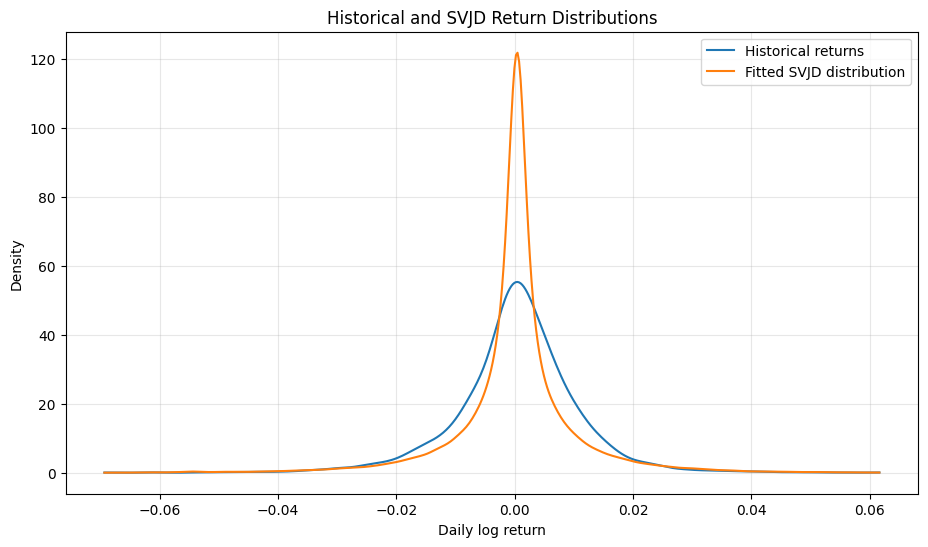

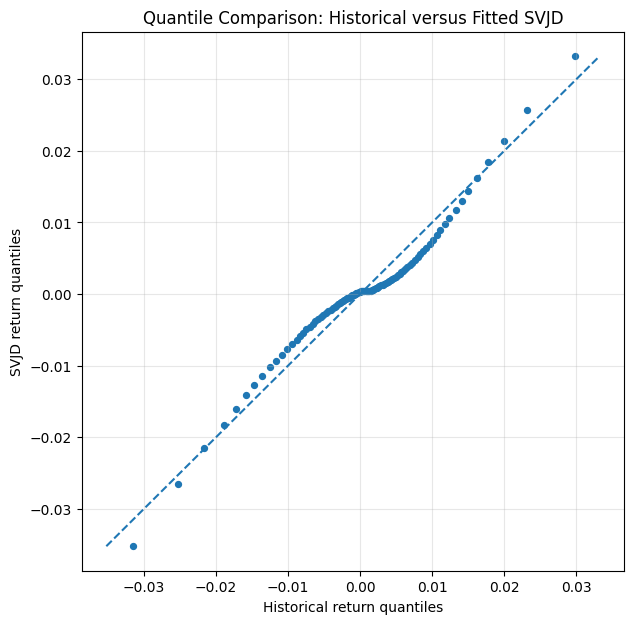

In [29]:
# ============================================================
# Independent simulation from the already-estimated SVJD model
# ============================================================

from scipy.stats import gaussian_kde

# Use the parameter estimates already stored in res
params_hat = res.x

# Long independent simulation for diagnostics
T_eval = 100_000
burn_in = 5_000

r_eval_full, v_eval_full = simulate_svjd(
    params_hat,
    T=T_eval + burn_in,
    dt=1/252,
    seed=9999
)

# Remove burn-in
r_sim = np.asarray(r_eval_full[burn_in:], dtype=float)
v_sim = np.asarray(v_eval_full[burn_in:], dtype=float)

# Clean samples
hist = np.asarray(r_actual, dtype=float)
hist = hist[np.isfinite(hist)]

sim = r_sim[np.isfinite(r_sim)]

print("Historical observations:", len(hist))
print("Simulated observations: ", len(sim))


# ============================================================
# Historical versus fitted SVJD density
# ============================================================

# Trim only the displayed horizontal range so a few extreme
# observations do not compress the center of the graph.
lo = min(
    np.quantile(hist, 0.001),
    np.quantile(sim, 0.001)
)

hi = max(
    np.quantile(hist, 0.999),
    np.quantile(sim, 0.999)
)

grid = np.linspace(lo, hi, 500)

kde_hist = gaussian_kde(hist)
kde_sim = gaussian_kde(sim)

plt.figure(figsize=(11, 6))

plt.plot(
    grid,
    kde_hist(grid),
    label="Historical returns"
)

plt.plot(
    grid,
    kde_sim(grid),
    label="Fitted SVJD distribution"
)

plt.title("Historical and SVJD Return Distributions")
plt.xlabel("Daily log return")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("SVJD_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


# ============================================================
# Quantile-to-quantile comparison
# ============================================================

probs = np.linspace(0.01, 0.99, 99)

q_hist = np.quantile(hist, probs)
q_sim = np.quantile(sim, probs)

qmin = min(q_hist.min(), q_sim.min())
qmax = max(q_hist.max(), q_sim.max())

plt.figure(figsize=(7, 7))

plt.scatter(
    q_hist,
    q_sim,
    s=18
)

plt.plot(
    [qmin, qmax],
    [qmin, qmax],
    linestyle="--"
)

plt.title("Quantile Comparison: Historical versus Fitted SVJD")
plt.xlabel("Historical return quantiles")
plt.ylabel("SVJD return quantiles")
plt.grid(True, alpha=0.3)
plt.savefig("SVJD_quantiles.png", dpi=300, bbox_inches="tight")
plt.show()

## Interpretation of the SVJD Distributional Fit

The figures compare the historical S&P 500 return distribution with returns generated from the estimated Stochastic Volatility Jump Diffusion (SVJD) model.

### Quantile Comparison

The quantile comparison provides an important diagnostic of the model.

If the fitted SVJD model reproduced the historical return distribution perfectly, the simulated and historical quantiles would lie along the $45^\circ$ line.

The fitted model tracks the historical distribution reasonably well, particularly toward the more extreme positive and negative returns. This suggests that the stochastic-volatility and jump components are able to reproduce some of the large movements observed in equity returns.

However, there is a noticeable S-shaped departure from the $45^\circ$ line around the center of the distribution.

For moderate negative returns, the simulated quantiles tend to be less negative than their historical counterparts. For moderate positive returns, the simulated quantiles also tend to be closer to zero than the corresponding historical returns.

Thus, the fitted SVJD model places **too much probability mass close to zero**.

### Density Comparison

The kernel density comparison gives a similar message.

The fitted SVJD distribution has a much sharper peak around zero than the historical return distribution. The historical distribution is broader near its center, while the fitted model concentrates a larger proportion of simulated observations very close to zero.

At the same time, the fitted SVJD distribution does generate substantial tail thickness.

This is important because one of the main purposes of introducing stochastic volatility and jumps is to improve the model's ability to represent unusually large market movements.

Thus, the model does a better job of representing the broad tail behavior than of reproducing the exact shape of the center of the historical distribution.

### Relation to Simulated GMM

These results illustrate an important feature of simulated GMM estimation:

> **Matching a selected set of empirical moments does not imply that the entire historical return distribution will be reproduced perfectly.**

The model was estimated by attempting to match the following historical moments:

- mean,
- variance,
- skewness,
- kurtosis,
- first-order return autocorrelation,
- first-order squared-return autocorrelation,
- mean absolute return,
- $1\%$ return quantile,
- $99\%$ return quantile.

The GMM criterion is

$$
Q(\psi)
=
g(\psi)'Wg(\psi),
$$

where

$$
g(\psi)
=
m_{\text{data}}
-
m_{\text{simulation}}(\psi).
$$

The estimator therefore chooses parameters that make these selected simulated moments as close as possible to the corresponding historical moments.

It does **not** directly require every point of the simulated probability distribution to coincide with the historical probability distribution.

This explains why the SVJD model can fit important features such as tail behavior reasonably well while still producing too much probability near zero.

### Interpretation of the Jump Estimates

The estimated jump parameters also suggest some caution in interpreting the jump component.

The estimated jump intensity is

$$
\hat{\lambda}=0.50.
$$

This is exactly equal to the initial value used in the optimization.

The estimated standard deviation of jump sizes is

$$
\hat{\sigma}_J \approx 0,
$$

and reached the lower bound imposed during estimation.

These two results suggest that the present set of GMM moments may not strongly identify all three components of the jump process separately:

$$
\lambda,
\qquad
\mu_J,
\qquad
\sigma_J.
$$

In particular, the estimator does not appear to be learning much about $\lambda$, while the estimate of $\sigma_J$ effectively eliminates variation in individual jump sizes.

The estimated average jump size,

$$
\hat{\mu}_J=-0.0552,
$$

implies an average jump of approximately $-5.5\%$ when a jump occurs.

Thus, the jump component is primarily being used to reproduce unusually large negative returns.

### Role of Stochastic Volatility

The stochastic-volatility component appears to be doing much of the important work in the model.

In particular, the estimated correlation between the return shock and the volatility shock is

$$
\hat{\rho}=-0.4975.
$$

This substantial negative correlation produces the leverage effect:

$$
\text{Negative Return Shock}
\rightarrow
\text{Higher Volatility}.
$$

The model therefore captures an important empirical characteristic of equity markets: negative market movements tend to be associated with increases in future volatility.

### Overall Assessment

The fitted SVJD model captures several important characteristics of historical equity returns:

- stochastic and persistent volatility,
- mean reversion in volatility,
- a strong leverage effect,
- fat tails,
- and unusually large negative returns.

The quantile plot indicates a reasonably good match in the tails, but the density comparison shows that the fitted model generates too many returns very close to zero.

Therefore, the SVJD model should not be judged solely by the minimized GMM objective function.

The graphical diagnostics reveal aspects of the return distribution that are not completely captured by the selected moment conditions.

The main lesson is:

$$
\boxed{
\text{Good moment matching does not necessarily imply a perfect distributional fit.}
}
$$

In [26]:
lambda_hat = res.x[5]   # annual jump intensity

daily_jump_prob = 1 - np.exp(-lambda_hat / 252)
annual_jump_prob = 1 - np.exp(-lambda_hat)

print(f"Annual jump intensity lambda: {lambda_hat:.4f}")
print(f"Daily probability of at least one jump: {100*daily_jump_prob:.3f}%")
print(f"Annual probability of at least one jump: {100*annual_jump_prob:.2f}%")
print(f"Expected number of days with at least one jump per year: {252*daily_jump_prob:.2f}")


Annual jump intensity lambda: 0.5000
Daily probability of at least one jump: 0.198%
Annual probability of at least one jump: 39.35%
Expected number of days with at least one jump per year: 0.50


In [ ]:
import pickle

svjd_results = {
    "params": res.x,
    "objective": res.fun,
    "success": res.success,
    "message": res.message,
    "actual_moments": actual_moments,
    "simulated_moments": sim_moments,
    "moments_table": moments_table
}

with open("svjd_complete_results.pkl", "wb") as f:
    pickle.dump(svjd_results, f)


## SVJD as a Distributional Risk Model

Once the SVJD parameters have been estimated, a **long post-burn-in simulation** approximates the fitted one-day return distribution.

From that simulated distribution we can estimate:

- the 5% lower-tail return quantile,
- the 1% lower-tail return quantile,
- Expected Shortfall,
- the probability of losses exceeding a chosen threshold.

These are **model-implied distributional risk measures**. They are not statements that the market will follow the particular simulated sequence generated by the random-number generator.

For example, a simulated 1% quantile of \(-0.038\) means that under the fitted SVJD distribution, about 1% of one-day simulated returns fall below \(-3.8\%\). It does **not** say which future date will experience such a loss.


In [27]:
# r_sim is the long post-burn-in simulation from the fitted model.

q05 = np.percentile(r_sim, 5)
q01 = np.percentile(r_sim, 1)

ES_05 = np.mean(r_sim[r_sim <= q05])
ES_01 = np.mean(r_sim[r_sim <= q01])

prob_loss_5pct = np.mean(r_sim < -0.05)

risk_table = pd.DataFrame({
    "Risk measure": [
        "5% lower-tail quantile",
        "1% lower-tail quantile",
        "Expected Shortfall, 5%",
        "Expected Shortfall, 1%",
        "P(return < -5%)"
    ],
    "Daily return": [
        q05,
        q01,
        ES_05,
        ES_01,
        prob_loss_5pct
    ]
})

display(risk_table)

print(f"5% lower-tail return quantile: {100*q05:.3f}%")
print(f"1% lower-tail return quantile: {100*q01:.3f}%")
print(f"Expected Shortfall at 5%:      {100*ES_05:.3f}%")
print(f"Expected Shortfall at 1%:      {100*ES_01:.3f}%")
print(f"Probability return < -5%:      {100*prob_loss_5pct:.3f}%")


,Risk measure,Daily return
0,5% lower-tail quantile,-0.015991
1,1% lower-tail quantile,-0.035206
2,"Expected Shortfall, 5%",-0.027915
3,"Expected Shortfall, 1%",-0.048734
4,P(return < -5%),0.003690


5% lower-tail return quantile: -1.599%
1% lower-tail return quantile: -3.521%
Expected Shortfall at 5%:      -2.791%
Expected Shortfall at 1%:      -4.873%
Probability return < -5%:      0.369%


In [28]:
tail_probs = np.array([0.01, 0.025, 0.05, 0.10, 0.90, 0.95, 0.975, 0.99])

tail_table = pd.DataFrame({
    "Probability": tail_probs,
    "Historical quantile": np.quantile(r_actual, tail_probs),
    "SVJD quantile": np.quantile(r_sim, tail_probs)
})

display(tail_table)


,Probability,Historical quantile,SVJD quantile
0,0.010,-0.031539,-0.035206
1,0.025,-0.023444,-0.023611
2,0.050,-0.017227,-0.015991
3,0.100,-0.011632,-0.009292
4,0.900,0.011729,0.009721
5,0.950,0.016273,0.016185
6,0.975,0.021685,0.023324
7,0.990,0.029800,0.033212


### Interpretation of the SVJD Quantile Comparison

The quantile comparison shows how closely the fitted SVJD model reproduces different parts of the historical S&P 500 return distribution.

At the $1\%$ quantile,

$$
q_{0.01}^{\text{hist}}=-3.15\%
$$

while

$$
q_{0.01}^{\text{SVJD}}=-3.52\%.
$$

Thus, the SVJD model generates a somewhat heavier extreme left tail than the historical data. In other words, the model slightly overstates the magnitude of the most extreme negative returns.

At the $2.5\%$ quantile,

$$
q_{0.025}^{\text{hist}}=-2.34\%
$$

and

$$
q_{0.025}^{\text{SVJD}}=-2.36\%.
$$

These values are extremely close, indicating a very good fit in this part of the lower tail.

At the $5\%$ quantile,

$$
q_{0.05}^{\text{hist}}=-1.72\%
$$

compared with

$$
q_{0.05}^{\text{SVJD}}=-1.60\%.
$$

The SVJD model therefore slightly understates losses at this point in the lower tail.

At the $10\%$ quantile,

$$
q_{0.10}^{\text{hist}}=-1.16\%
$$

while

$$
q_{0.10}^{\text{SVJD}}=-0.93\%.
$$

Here the difference is more noticeable. The simulated returns are too close to zero, indicating that the fitted SVJD model places too much probability mass near the center of the distribution.

A similar pattern appears on the positive side.

At the $90\%$ quantile,

$$
q_{0.90}^{\text{hist}}=1.17\%
$$

while

$$
q_{0.90}^{\text{SVJD}}=0.97\%.
$$

Thus, the model understates moderately large positive returns.

At the $95\%$ quantile,

$$
q_{0.95}^{\text{hist}}=1.63\%
$$

and

$$
q_{0.95}^{\text{SVJD}}=1.62\%.
$$

This is an extremely close match.

At the $97.5\%$ quantile,

$$
q_{0.975}^{\text{hist}}=2.17\%
$$

while

$$
q_{0.975}^{\text{SVJD}}=2.33\%.
$$

The model generates slightly larger positive returns in this part of the upper tail.

Finally, at the $99\%$ quantile,

$$
q_{0.99}^{\text{hist}}=2.98\%
$$

compared with

$$
q_{0.99}^{\text{SVJD}}=3.32\%.
$$

Thus, as in the extreme left tail, the SVJD model produces a somewhat heavier extreme right tail than observed historically.

### Overall Interpretation

The fitted SVJD model reproduces the tails of the historical S&P 500 return distribution reasonably well.

In particular, the fit is very close around the $2.5\%$, $5\%$, $95\%$, and $97.5\%$ quantiles.

However, two systematic differences remain:

- The model produces too much probability close to zero, which is visible at the $10\%$ and $90\%$ quantiles.
- The model produces somewhat heavier extreme tails, particularly at the $1\%$ and $99\%$ quantiles.

This pattern is consistent with the S-shaped deviation observed in the quantile comparison graph.

The main conclusion is:

$$
\boxed{
\text{The SVJD model captures extreme-risk behavior reasonably well,
but does not reproduce the center of the return distribution perfectly.}
}
$$

## Main Lesson: Why Estimate an SVJD Model?

If our only objective were to calculate historical tail probabilities or quantiles, we would not need an SVJD model.

For example, the historical $1\%$ return quantile can be calculated directly from the observed S&P 500 returns:

$$
q_{0.01}^{Hist}
=
-3.15\%.
$$

This tells us what occurred in the historical sample.

The purpose of the SVJD model is different.

Historical quantiles answer the question:

> **What did the distribution of returns look like in the observed historical sample?**

The SVJD model asks:

> **What stochastic process could have generated the important distributional and volatility characteristics of those historical returns?**

This distinction matters because the SVJD model provides a complete stochastic data-generating process rather than simply a collection of historical statistics.

### 1. Time-Varying Risk

A historical quantile is essentially an unconditional measure based on the entire sample.

The SVJD model contains a stochastic variance state $v_t$. Consequently, the distribution of future returns can depend on current market conditions:

$$
r_{t+1}\mid v_t.
$$

Risk following a quiet market period need not be the same as risk following a major volatility shock.

### 2. Rare Events

Historical data contain relatively few observations in the extreme tails.

With approximately 9,000 daily observations, a $1\%$ historical tail contains roughly 90 observations.

A $0.1\%$ tail contains only about

$$
9000(0.001)=9
$$

observations.

An estimated stochastic model can generate a much larger simulated sample and therefore allows us to study rare-event probabilities that are difficult to estimate directly from a limited historical sample.

The tradeoff is that these estimates depend on the validity of the assumed model.

### 3. Dynamic Scenarios

The SVJD model can generate complete future paths of returns and volatility.

This allows us to examine questions such as:

- What happens to volatility following a large negative return?
- How persistent are volatility shocks?
- What is the probability of a large cumulative loss over several days?
- What is Expected Shortfall?
- How might returns behave during hypothetical stress scenarios?

Historical quantiles alone do not provide a dynamic model for answering these questions.

### 4. Econometric Purpose

For this course, the SVJD model also provides an important application of simulated GMM.

We estimate parameters governing:

- expected returns,
- mean reversion in volatility,
- stochastic volatility shocks,
- correlation between return and volatility shocks,
- jump frequency,
- jump size.

The exercise therefore demonstrates how nonlinear econometric methods can estimate a complicated stochastic process that cannot be summarized by a simple linear regression.

### The Central Distinction

$$
\boxed{
\text{Historical Distribution}
\quad\Longrightarrow\quad
\text{Describes what occurred}
}
$$

while

$$
\boxed{
\text{Estimated SVJD Process}
\quad\Longrightarrow\quad
\text{Provides a model for what could occur}
}
$$

The SVJD model should therefore not automatically replace historical quantiles. Historical quantiles provide a useful benchmark and require fewer modeling assumptions.

The value of the SVJD model arises when we want a dynamic stochastic model for volatility, tail risk, simulation, and hypothetical future scenarios.